In [1]:
import os
import sys
from pathlib import Path

parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir/'src'))
from map2grid import *

import string
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime

# Retrieve OSM data

In [2]:
# '''
#     Extract power infrastructure data from OSM
#     Package: osm-flex (https://github.com/osm-flex/osm-flex)
#     `vietnam-latest.osm.pbf` was downloaded on 16-5-2024.
#     You can skip this step and read the geopakage data in "../data/osm" directly, see the cell below.
# '''
# gdf_power = load_osm_data('VNM')

# output_path="../data/osm"
# gens = import_osm_infras(gdf_power, 'power', ['plant', 'generator'], output_path)
# lines = import_osm_infras(gdf_power, 'power', ['line', 'minor_line', 'cable'], output_path)
# subs = import_osm_infras(gdf_power, 'power', ['substation'], output_path)
# trafos = import_osm_infras(gdf_power, 'power', ['transformer'], output_path)

In [3]:
'''
    If you have already run the above code once,
    you can directly read the data from saved GeoPackage files.
'''
lines = gpd.read_file("../data/osm/line.gpkg", epsg=32648, driver='GPKG')
subs = gpd.read_file("../data/osm/substation.gpkg", epsg=32648, driver='GPKG')
gens = gpd.read_file("../data/osm/plant.gpkg", epsg=32648, driver='GPKG')

c:\Users\mye500\AppData\Local\anaconda3\envs\py310\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option EPSG
  return ogr_read(
c:\Users\mye500\AppData\Local\anaconda3\envs\py310\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(
c:\Users\mye500\AppData\Local\anaconda3\envs\py310\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option EPSG
  return ogr_read(
c:\Users\mye500\AppData\Local\anaconda3\envs\py310\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(
c:\Users\mye500\AppData\Local\anaconda3\envs\py310\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option EPSG
  return ogr_read(
c:\Users\mye500\AppData\Local\anaconda3\envs\py310\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GPKG does not support open option 

In [4]:
reference_gdf = gpd.read_file(f'../data/osm/power_substation_vietnam.gpkg')
subs = add_missing_osm_ids(subs, reference_gdf)

Number of unmatched geometries: 0


In [5]:
buffer_distance = 500

# Define boolean options
bool_options = {
    'plot_ways_original': True,  # Visualize all selected lines (original dataset)
    'histogram_length_busbars': True,  # Visualize the length of busbars
    'histogram_distances_between_endpoints': True,  # Visualize the distances between endpoints
    'histogram_stacked_endnodes': True,  # Visualize the number of stacked endpoints
    'plot_stacked_endnodes': True,  # Visualize all stacked endpoints on the map
}

In [6]:
def calculate_length_route(data):
    """
    Calculate the length of each line in kilometers, considering a slack factor of 1.2
    """
    data['Length'] = data['geometry'].length * 1.2 / 1000
    return data

In [7]:
lines = calculate_length_route(lines)

In [8]:
lines_voltage = count_voltage_levels(lines)

Start counting voltage levels...
Voltage levels count:
Voltage level 110 kV: 2214
Voltage level 220 kV: 989
Voltage level 500 kV: 3080
Count of rows with None voltage: 1972


In [9]:
lines_cables = count_cables(lines_voltage)

Start counting cables per way...
Number of rows missing both cables and circuits: 2409
   ATTENTION! Both "cables" and "circuits" are missing for ID 176708144. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 241255651. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 306551278. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 306551280. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 307638313. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 307638318. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 307777845. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 307777860. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are missing for ID 400152692. Setting circuits to 1.
   ATTENTION! Both "cables" and "circuits" are mi

Start deleting ways with type "busbar" or "bay"...
   ATTENTION! Way Element ID 1271355297 has type "busbar" or "bay", but is too long.
               Length: 32.37 km of max. 1.0 km
               This way won't be added to the "busbar" exception list.
   ATTENTION! Way Element ID 1293378775 has type "busbar" or "bay", but is too long.
               Length: 31.64 km of max. 1.0 km
               This way won't be added to the "busbar" exception list.


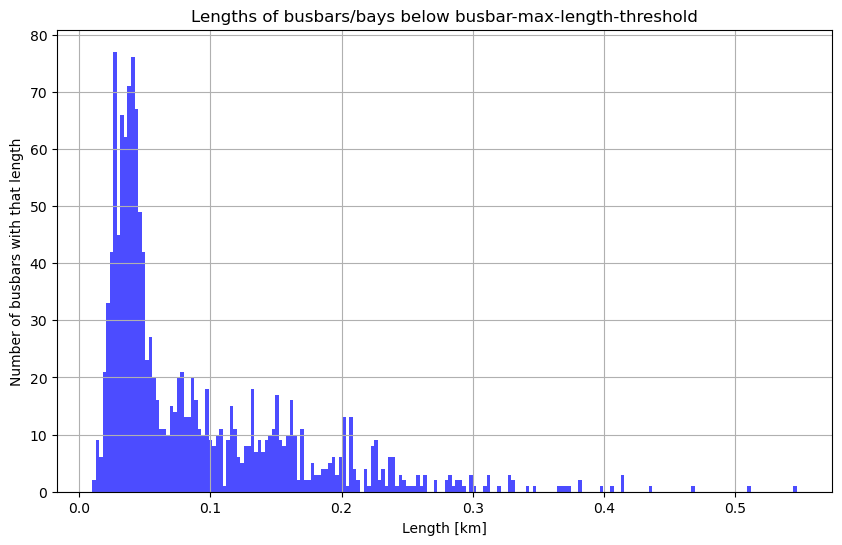

   ... there are 1391 busbars/bays in total
   ... 1389 busbars have been deleted
   ... finished! (1.432 seconds) 



In [10]:
lines_delete_busbar, data_busbars = delete_busbars(lines_cables, bool_options)

In [11]:
lines_dc, dc_candidates = count_possible_dc(lines_delete_busbar)

Start detecting lines which could be DC lines...
   ... 727 ways could potentially be a DC line.
   ... Please refer to dc_candidates for further checks.
   ... finished! (0.608 seconds) 



---------------------------

In [12]:
lines_gdf = gpd.GeoDataFrame(lines_dc, geometry=lines_dc['geometry'])
nodes_gdf = extract_unique_endpoints(lines_gdf)

In [13]:
lines_endnodes = add_endnodes_to_lines(lines_gdf, nodes_gdf)  # Add columns node1 and node2 to lines

In [14]:
subs_update = transform_osm_subs(subs, buffer_distance=200)

In [16]:
data_ways_update_osm_id, nodes_in_osm_subs = add_osm_ids_to_data(lines_endnodes, subs_update)

In [ ]:
subs

   ... start visualizing all distances in a histogram ...


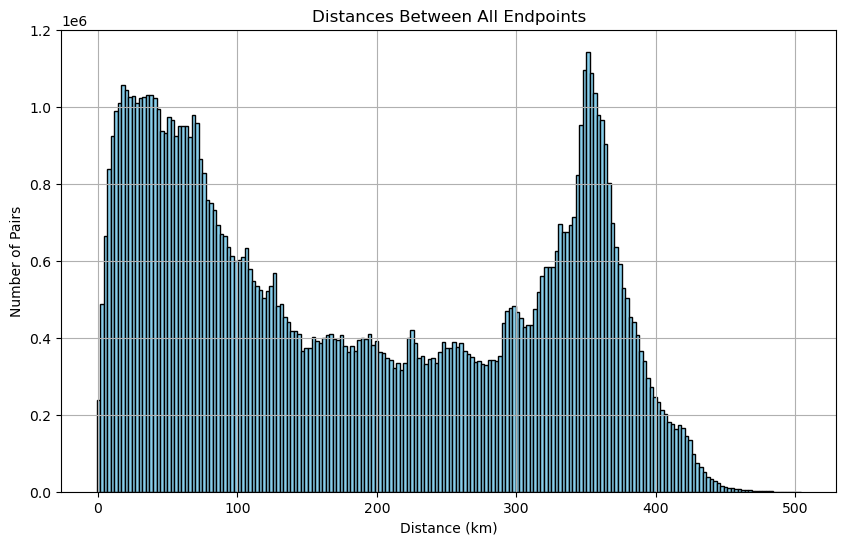

In [17]:
M = calc_distances_between_endpoints(lines_endnodes, bool_options)

Start finding all stacked endnodes...
... 9860 endnodes are stacked!
... finished! (1.906 seconds)

Reprojecting CRS from EPSG:32648 to EPSG:32648.


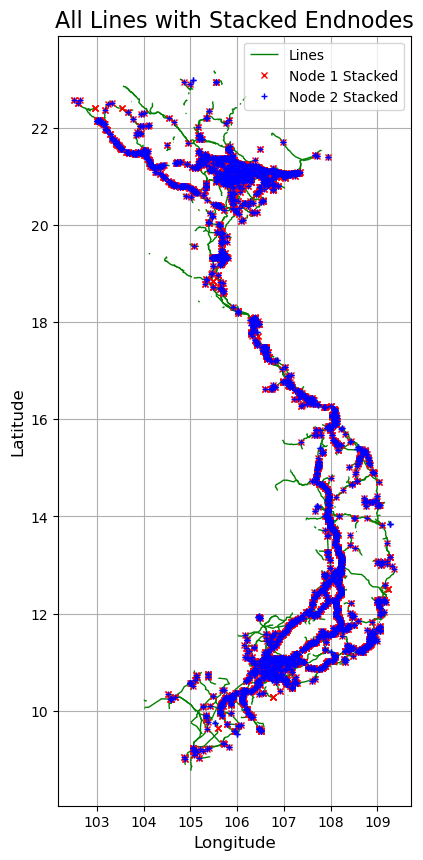

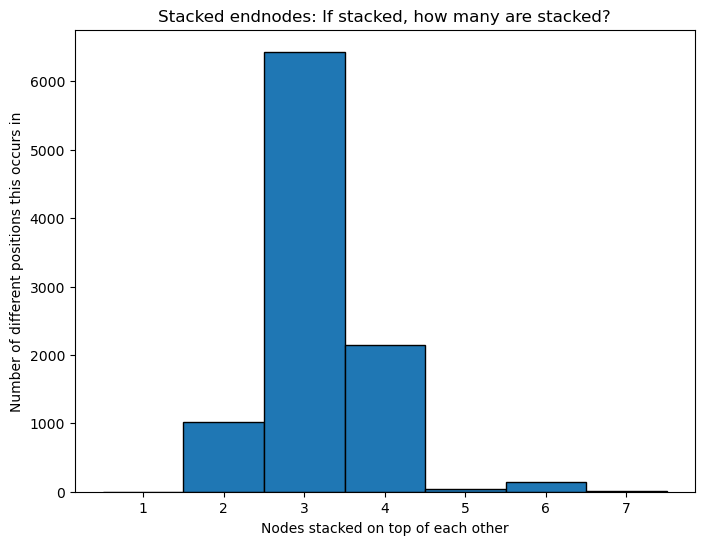

In [19]:
data_ways_stacked, nodes_stacked_pairs = calc_stacked_endnodes(data_ways_update_osm_id, M, bool_options)

In [20]:
nodes_stacked_grouped = group_nodes(nodes_stacked_pairs)

Start grouping all pairs from "pairs_input" (may take a few seconds)...
   ... 9860 nodes will be grouped together in 3231 groups,
       with an average of 3.05 nodes per group.
   ... finished! (3.249 seconds)



In [21]:
data_ways_group_stacked_nodes = group_stacked_endnodes(lines_endnodes, nodes_gdf, nodes_stacked_grouped)

Completed updating coordinates for stacked groups.


In [22]:
data_ways_final_coords = add_final_coordinates(data_ways_group_stacked_nodes)

Start adding final coordinates...
... finished!


In [23]:
data_ways_delete, data_singular_ways = delete_singular_ways(data_ways_final_coords, 'ID_node1_final', 'ID_node2_final')

Start deleting ways which have the same endpoints after grouping...
   ... 1073 ways were deleted!
   ... finished! (0.035 seconds)


EPSG:4326 EPSG:4326 EPSG:4326
Start plotting original ways... (takes a few seconds)


\\pscst001.scistor.vu.nl\BETA-IVM-BAZIS\mye500\projects\Map2Grid\src\map2grid.py:1468: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "cx-" (-> color='c'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'cx-', color="#dec5e3", linewidth=1, label="Busbars")
\\pscst001.scistor.vu.nl\BETA-IVM-BAZIS\mye500\projects\Map2Grid\src\map2grid.py:1471: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "cx-" (-> color='c'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'cx-', color="#dec5e3", linewidth=1)
\\pscst001.scistor.vu.nl\BETA-IVM-BAZIS\mye500\projects\Map2Grid\src\map2grid.py:1480: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "kx-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'kx-', color="#73d2de", linewidth=1, label="Deleted Ways")
\\pscst001.scistor.vu.nl\BETA-IVM-BAZIS\mye500\projects

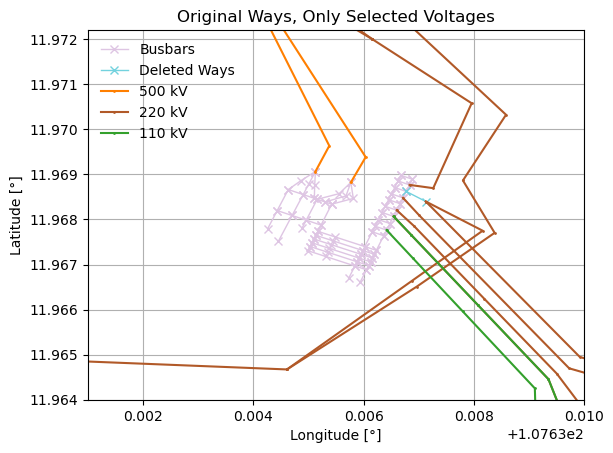

In [24]:
plot_ways_original(data_ways_delete, data_busbars, bool_options, data_singular_ways)

osm_id of the substation presented above is 1192268300.

In [25]:
# data_ways_clone = add_lineID_clone_ways(data_ways_delete)

In [26]:
table_lines = fill_line_voltage(data_ways_delete)

In [27]:
table_lines_update = table_lines.dropna(subset=['voltage'])

In [35]:
print(len(table_lines_update))
print(len(table_lines))

5291
5793


In [30]:
output_dir = '..\outputs'
export_data(table_lines_update, output_dir)

Start exporting data to Excel files... (may take a few seconds)
INFO: Exported lines to ..\outputs\tbl_Lines_VN.xlsx
INFO: Exported Nodes to ..\outputs\tbl_Nodes_VN_500m.xlsx
... finished!
